In [6]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pickle

### Loading and splitting data

In [7]:
os.makedirs("saved_models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

df = pd.read_csv("data/cleaned_reviews.csv")

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## TF-IDF

### Defining the tfidf based feature sets

In [8]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

feature_names = vectorizer.get_feature_names_out()
idf_scores = vectorizer.idf_

idf_df = pd.DataFrame({'term': feature_names, 'idf': idf_scores}).sort_values('idf', ascending=False)

# print("TOP 20 HIGHEST IDF TERMS")
# print(idf_df.head(10).to_string(index=False))

# print("TOP 10 LOWEST IDF TERMS")
# print(idf_df.tail(10).to_string(index=False))

## Visualizing top words

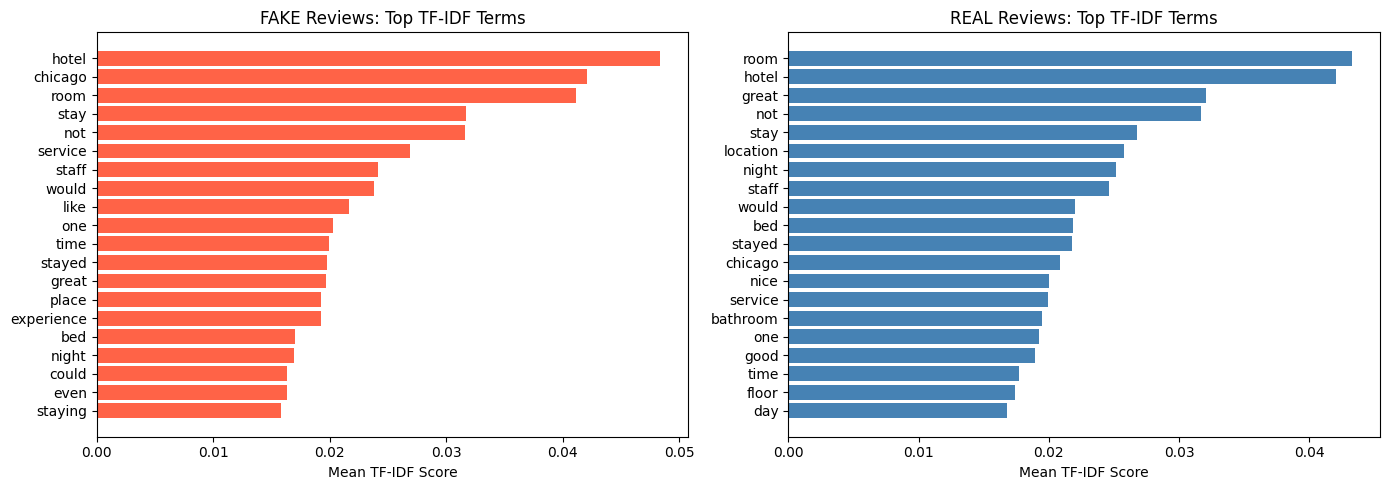

In [9]:
def get_top_tfidf_terms(X_tfidf, y, label, feature_names, n=20):
    label_filter = (y.values == label)
    mean_tfidf = np.asarray(X_tfidf[label_filter].mean(axis=0)).flatten()
    top_indices = mean_tfidf.argsort()[-n:][::-1] #mean of top vals in descending order
    return [(feature_names[i], mean_tfidf[i]) for i in top_indices]

y_train_arr = y_train.reset_index(drop=True)

top_fake = get_top_tfidf_terms(X_train_tfidf, y_train_arr, label=1, feature_names=feature_names)
top_real = get_top_tfidf_terms(X_train_tfidf, y_train_arr, label=0, feature_names=feature_names)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

fake_terms  = [x[0] for x in top_fake]
fake_scores = [x[1] for x in top_fake]
real_terms  = [x[0] for x in top_real]
real_scores = [x[1] for x in top_real]


axes[0].barh(fake_terms[::-1], fake_scores[::-1], color='tomato')
axes[0].set_title("FAKE Reviews: Top TF-IDF Terms")
axes[0].set_xlabel("Mean TF-IDF Score")

axes[1].barh(real_terms[::-1], real_scores[::-1], color='steelblue')
axes[1].set_title("REAL Reviews: Top TF-IDF Terms")
axes[1].set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.savefig("plots/tfidf_terms.png", dpi=150, bbox_inches='tight')
plt.show()

## Saving models and data

In [10]:
pickle.dump(vectorizer, open("saved_models/tfidf_vectorizer.pkl", "wb"))

np.save("data/X_train_tfidf.npy", X_train_tfidf.toarray())
np.save("data/X_test_tfidf.npy",  X_test_tfidf.toarray())
np.save("data/y_train.npy",y_train.values)
np.save("data/y_test.npy",  y_test.values)

X_train.reset_index(drop=True).to_csv("data/X_train_text.csv", index=False)
X_test.reset_index(drop=True).to_csv("data/X_test_text.csv",   index=False)